In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import (
    shapiro,
    normaltest,
    ttest_ind,
    mannwhitneyu,
    chi2_contingency,
    f_oneway,
    kruskal,
    pointbiserialr
)

import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [4]:
# Generate  healthcare dataset


n = 3000

age = np.random.normal(42, 13, n).astype(int)
age = np.clip(age, 18, 80)

bmi = np.random.normal(30, 6, n)
bmi = np.clip(bmi, 16, 55)

glucose = np.random.normal(120, 32, n)
glucose = np.clip(glucose, 60, 260)

blood_pressure = np.random.normal(75, 12, n)
blood_pressure = np.clip(blood_pressure, 45, 130)

insulin = np.random.lognormal(mean=4.6, sigma=0.7, size=n)
insulin = np.clip(insulin, 10, 900)

cholesterol = np.random.normal(200, 38, n)
cholesterol = np.clip(cholesterol, 110, 380)

exercise_hours = np.random.normal(3.5, 2.0, n)
exercise_hours = np.clip(exercise_hours, 0, 12)

family_history = np.random.binomial(1, 0.32, n)

# Logistic formula for disease probability
logit = (
    -9
    + 0.035 * age
    + 0.055 * bmi
    + 0.032 * glucose
    + 0.015 * blood_pressure
    + 0.004 * cholesterol
    + 0.85 * family_history
    - 0.20 * exercise_hours
)

probability = 1 / (1 + np.exp(-logit))

outcome = np.random.binomial(1, probability)

health_df = pd.DataFrame({
    "Age": age,
    "BMI": np.round(bmi, 2),
    "Glucose": np.round(glucose, 2),
    "BloodPressure": np.round(blood_pressure, 2),
    "Insulin": np.round(insulin, 2),
    "Cholesterol": np.round(cholesterol, 2),
    "ExerciseHours": np.round(exercise_hours, 2),
    "FamilyHistory": family_history,
    "Disease": outcome
})

print("Dataset shape:", health_df.shape)
print(health_df.head())

Dataset shape: (3000, 9)
   Age    BMI  Glucose  BloodPressure  Insulin  Cholesterol  ExerciseHours  \
0   24  22.44    75.54          62.90   101.51       245.82           2.94   
1   41  31.53    89.77          74.72   117.65       175.87           1.90   
2   51  30.86   125.54          66.23   260.65       110.00           3.61   
3   45  25.88   179.36          85.49    33.49       214.05           3.82   
4   54  34.68   156.86          66.07   151.40       171.07           2.96   

   FamilyHistory  Disease  
0              0        0  
1              0        0  
2              1        1  
3              0        1  
4              1        1  


In [5]:
# Data overview


print("\nData Info:")
print(health_df.info())

print("\nMissing Values:")
print(health_df.isnull().sum())

print("\nDuplicate Rows:")
print(health_df.duplicated().sum())

print("\nBasic Description:")
print(health_df.describe())



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            3000 non-null   int64  
 1   BMI            3000 non-null   float64
 2   Glucose        3000 non-null   float64
 3   BloodPressure  3000 non-null   float64
 4   Insulin        3000 non-null   float64
 5   Cholesterol    3000 non-null   float64
 6   ExerciseHours  3000 non-null   float64
 7   FamilyHistory  3000 non-null   int32  
 8   Disease        3000 non-null   int32  
dtypes: float64(6), int32(2), int64(1)
memory usage: 187.6 KB
None

Missing Values:
Age              0
BMI              0
Glucose          0
BloodPressure    0
Insulin          0
Cholesterol      0
ExerciseHours    0
FamilyHistory    0
Disease          0
dtype: int64

Duplicate Rows:
0

Basic Description:
               Age          BMI      Glucose  BloodPressure      Insulin  \
count  3000.000

In [6]:
# Descriptive statistics


numeric_cols = [
    "Age",
    "BMI",
    "Glucose",
    "BloodPressure",
    "Insulin",
    "Cholesterol",
    "ExerciseHours"
]

desc_stats = health_df[numeric_cols].agg([
    "mean",
    "median",
    "std",
    "var",
    "min",
    "max",
    "skew",
    "kurt"
]).T

desc_stats["range"] = health_df[numeric_cols].max() - health_df[numeric_cols].min()
desc_stats["IQR"] = health_df[numeric_cols].quantile(0.75) - health_df[numeric_cols].quantile(0.25)

print("\nDescriptive Statistics:")
print(desc_stats)




Descriptive Statistics:
                     mean   median        std          var    min     max  \
Age             41.856667   42.000  12.485088   155.877415   18.0   80.00   
BMI             29.986613   29.965   6.112496    37.362609   16.0   51.79   
Glucose        120.208920  118.975  31.606222   998.953252   60.0  237.45   
BloodPressure   75.281720   75.485  11.902691   141.674057   45.0  121.06   
Insulin        124.275470   99.890  94.225596  8878.462868   10.0  900.00   
Cholesterol    199.573613  200.465  37.782276  1427.500403  110.0  334.95   
ExerciseHours    3.574080    3.515   1.939232     3.760622    0.0   10.76   

                   skew       kurt   range      IQR  
Age            0.134601  -0.338935   62.00  17.0000  
BMI            0.070102  -0.209476   35.79   8.4100  
Glucose        0.199156  -0.299262  177.45  44.3575  
BloodPressure  0.024388  -0.040140   76.06  16.4100  
Insulin        2.567931  11.383749  890.00  95.1025  
Cholesterol   -0.030329  -0.172515

In [7]:
# Compare disease vs non-disease groups


group_summary = health_df.groupby("Disease")[numeric_cols].mean()

print("\nAverage Health Metrics by Disease Group:")
print(group_summary)




Average Health Metrics by Disease Group:
               Age        BMI     Glucose  BloodPressure     Insulin  \
Disease                                                                
0        40.372387  29.336601  110.497761      74.412635  122.949950   
1        44.139594  30.986379  135.145372      76.618435  126.314213   

         Cholesterol  ExerciseHours  
Disease                              
0         198.175253       3.793256  
1         201.724391       3.236971  


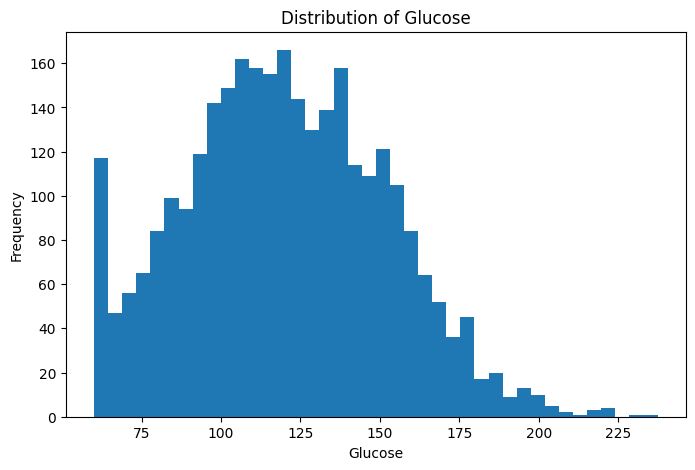

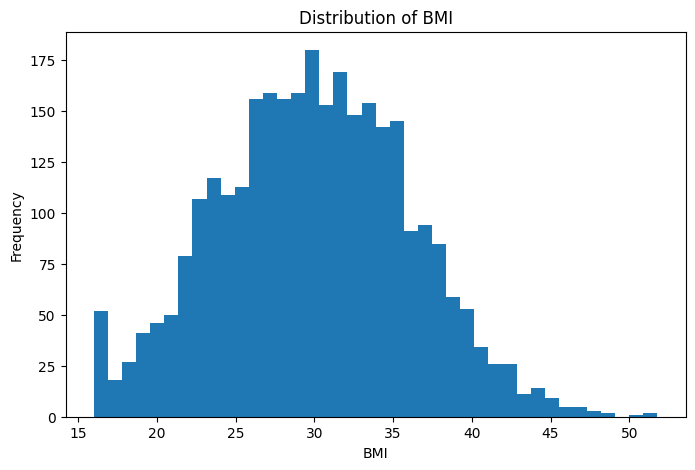

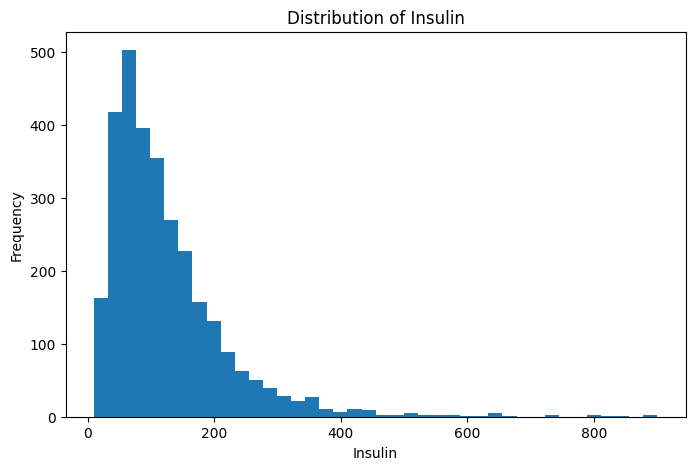

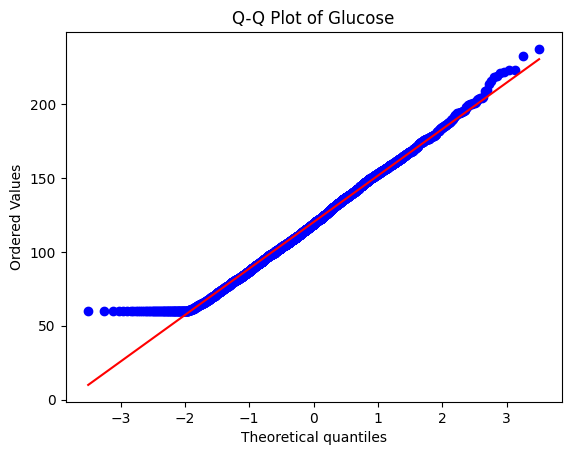

In [8]:
# Distribution analysis

plt.figure(figsize=(8, 5))
plt.hist(health_df["Glucose"], bins=40)
plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(health_df["BMI"], bins=40)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(health_df["Insulin"], bins=40)
plt.title("Distribution of Insulin")
plt.xlabel("Insulin")
plt.ylabel("Frequency")
plt.show()

stats.probplot(health_df["Glucose"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Glucose")
plt.show()



In [9]:
# Normality tests


sample_glucose = health_df["Glucose"].sample(500, random_state=42)

shapiro_stat, shapiro_p = shapiro(sample_glucose)
normal_stat, normal_p = normaltest(sample_glucose)

print("\nNormality Tests for Glucose:")
print("Shapiro statistic:", shapiro_stat)
print("Shapiro p-value:", shapiro_p)
print("D'Agostino statistic:", normal_stat)
print("D'Agostino p-value:", normal_p)

if shapiro_p < 0.05:
    print("Conclusion: Glucose is not normally distributed.")
else:
    print("Conclusion: Glucose appears approximately normal.")




Normality Tests for Glucose:
Shapiro statistic: 0.9891157144341682
Shapiro p-value: 0.0009048471804777296
D'Agostino statistic: 4.3398321124569605
D'Agostino p-value: 0.11418720181291395
Conclusion: Glucose is not normally distributed.


In [10]:
# Z-score analysis


health_df["Glucose_Zscore"] = stats.zscore(health_df["Glucose"])

high_glucose_z = health_df[health_df["Glucose_Zscore"] > 2]

print("\nPatients with Glucose more than 2 standard deviations above average:")
print(high_glucose_z[["Age", "Glucose", "Glucose_Zscore", "Disease"]].head())
print("Number of high-glucose z-score patients:", len(high_glucose_z))


Patients with Glucose more than 2 standard deviations above average:
     Age  Glucose  Glucose_Zscore  Disease
38    37   191.26        2.248384        1
51    51   213.49        2.951844        1
60    39   209.00        2.809760        1
141   44   187.93        2.143007        1
239   34   186.14        2.086364        1
Number of high-glucose z-score patients: 73


In [11]:
# Outlier detection using IQR


Q1 = health_df["Insulin"].quantile(0.25)
Q3 = health_df["Insulin"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

insulin_outliers = health_df[
    (health_df["Insulin"] < lower_bound) |
    (health_df["Insulin"] > upper_bound)
]

print("\nInsulin Outlier Detection:")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of insulin outliers:", len(insulin_outliers))



Insulin Outlier Detection:
Lower bound: -80.26375
Upper bound: 300.14625
Number of insulin outliers: 144


In [12]:
# Probability and conditional probability


p_disease = np.mean(health_df["Disease"] == 1)

p_disease_high_glucose = np.mean(
    health_df[health_df["Glucose"] > 140]["Disease"] == 1
)

p_disease_high_bmi = np.mean(
    health_df[health_df["BMI"] > 30]["Disease"] == 1
)

p_disease_high_glucose_high_bmi = np.mean(
    health_df[
        (health_df["Glucose"] > 140) &
        (health_df["BMI"] > 30)
    ]["Disease"] == 1
)

print("\nProbability Analysis:")
print("P(Disease):", p_disease)
print("P(Disease | Glucose > 140):", p_disease_high_glucose)
print("P(Disease | BMI > 30):", p_disease_high_bmi)
print("P(Disease | Glucose > 140 and BMI > 30):", p_disease_high_glucose_high_bmi)




Probability Analysis:
P(Disease): 0.394
P(Disease | Glucose > 140): 0.6334563345633456
P(Disease | BMI > 30): 0.44013377926421404
P(Disease | Glucose > 140 and BMI > 30): 0.6962962962962963


In [ ]:
# Bayes theorem example


# Example:
# Prevalence = P(Disease)
# Sensitivity = P(Test Positive | Disease)
# Specificity = P(Test Negative | No Disease)

prevalence = p_disease
sensitivity = 0.90
specificity = 0.85

p_positive_given_disease = sensitivity
p_positive_given_no_disease = 1 - specificity
p_no_disease = 1 - prevalence

# Bayes theorem:
# P(Disease | Positive) =
# P(Positive | Disease) * P(Disease)
# /
# [P(Positive | Disease) * P(Disease) + P(Positive | No Disease) * P(No Disease)]

p_disease_given_positive = (
    p_positive_given_disease * prevalence
) / (
    p_positive_given_disease * prevalence
    + p_positive_given_no_disease * p_no_disease
)

print("\nBayes Theorem Medical Test Example:")
print("Disease prevalence:", prevalence)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("P(Disease | Positive Test):", p_disease_given_positive)




Bayes Theorem Medical Test Example:
Disease prevalence: 0.394
Sensitivity: 0.9
Specificity: 0.85
P(Disease | Positive Test): 0.795959595959596


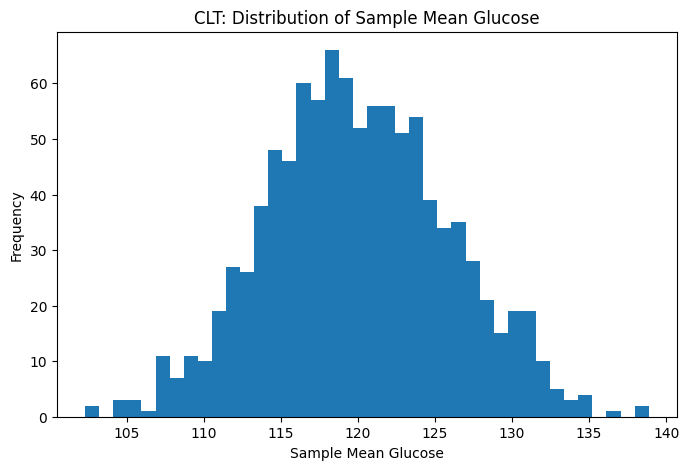


CLT Analysis for Glucose:
Original glucose mean: 120.20892
Mean of sample means: 120.02503433333332
Standard deviation of sample means: 5.918512444247297


In [14]:
# Central Limit Theorem


sample_means = []

for i in range(1000):
    sample = health_df["Glucose"].sample(30, replace=True)
    sample_means.append(sample.mean())

plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=40)
plt.title("CLT: Distribution of Sample Mean Glucose")
plt.xlabel("Sample Mean Glucose")
plt.ylabel("Frequency")
plt.show()

print("\nCLT Analysis for Glucose:")
print("Original glucose mean:", health_df["Glucose"].mean())
print("Mean of sample means:", np.mean(sample_means))
print("Standard deviation of sample means:", np.std(sample_means))

In [15]:
# Confidence intervals


# CI for mean glucose
mean_glucose = health_df["Glucose"].mean()
std_glucose = health_df["Glucose"].std()
n_obs = len(health_df)

confidence_level = 0.95
alpha = 1 - confidence_level

t_critical = stats.t.ppf(1 - alpha / 2, df=n_obs - 1)
margin_error = t_critical * (std_glucose / np.sqrt(n_obs))

ci_lower = mean_glucose - margin_error
ci_upper = mean_glucose + margin_error

print("\n95% Confidence Interval for Mean Glucose:")
print("Mean glucose:", mean_glucose)
print("CI lower:", ci_lower)
print("CI upper:", ci_upper)


# CI for disease proportion
disease_count = health_df["Disease"].sum()
total_count = len(health_df)

prop_ci_lower, prop_ci_upper = proportion_confint(
    count=disease_count,
    nobs=total_count,
    alpha=0.05,
    method="wilson"
)

print("\n95% Confidence Interval for Disease Proportion:")
print("Disease proportion:", p_disease)
print("CI lower:", prop_ci_lower)
print("CI upper:", prop_ci_upper)


# CI for difference in mean glucose between disease and non-disease
disease_glucose = health_df[health_df["Disease"] == 1]["Glucose"]
non_disease_glucose = health_df[health_df["Disease"] == 0]["Glucose"]

mean_diff = disease_glucose.mean() - non_disease_glucose.mean()

se_diff = np.sqrt(
    disease_glucose.var() / len(disease_glucose)
    + non_disease_glucose.var() / len(non_disease_glucose)
)

df_welch = (
    (disease_glucose.var() / len(disease_glucose)
     + non_disease_glucose.var() / len(non_disease_glucose)) ** 2
) / (
    ((disease_glucose.var() / len(disease_glucose)) ** 2) / (len(disease_glucose) - 1)
    + ((non_disease_glucose.var() / len(non_disease_glucose)) ** 2) / (len(non_disease_glucose) - 1)
)

t_critical = stats.t.ppf(0.975, df=df_welch)

ci_lower = mean_diff - t_critical * se_diff
ci_upper = mean_diff + t_critical * se_diff

print("\n95% CI for Difference in Mean Glucose:")
print("Mean difference:", mean_diff)
print("CI lower:", ci_lower)
print("CI upper:", ci_upper)




95% Confidence Interval for Mean Glucose:
Mean glucose: 120.20892
CI lower: 119.07747002537083
CI upper: 121.34036997462918

95% Confidence Interval for Disease Proportion:
Disease proportion: 0.394
CI lower: 0.37666096460722465
CI upper: 0.4116101513225445

95% CI for Difference in Mean Glucose:
Mean difference: 24.647610974295404
CI lower: 22.472522542743047
CI upper: 26.82269940584776


In [16]:
# Two-sample t-test
# Disease vs non-disease glucose


t_stat, p_value = ttest_ind(
    disease_glucose,
    non_disease_glucose,
    equal_var=False
)

print("\nTwo-Sample T-Test:")
print("H0: Mean glucose is equal for disease and non-disease groups")
print("H1: Mean glucose is different")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Mean glucose differs significantly between groups.")
else:
    print("Conclusion: No significant glucose difference found.")




Two-Sample T-Test:
H0: Mean glucose is equal for disease and non-disease groups
H1: Mean glucose is different
t-statistic: 22.221127840402136
p-value: 1.349120170832767e-99
Conclusion: Mean glucose differs significantly between groups.


In [17]:
# Mann-Whitney U test
# For non-normal insulin


disease_insulin = health_df[health_df["Disease"] == 1]["Insulin"]
non_disease_insulin = health_df[health_df["Disease"] == 0]["Insulin"]

u_stat, p_value = mannwhitneyu(
    disease_insulin,
    non_disease_insulin,
    alternative="two-sided"
)

print("\nMann-Whitney U Test:")
print("H0: Insulin distribution is same across groups")
print("H1: Insulin distribution differs")
print("U-statistic:", u_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Insulin distribution differs significantly between groups.")
else:
    print("Conclusion: No significant insulin distribution difference found.")




Mann-Whitney U Test:
H0: Insulin distribution is same across groups
H1: Insulin distribution differs
U-statistic: 1084976.0
p-value: 0.6494270755422848
Conclusion: No significant insulin distribution difference found.


In [18]:
# BMI categories and chi-square test


def bmi_category(value):
    if value < 18.5:
        return "Underweight"
    elif value < 25:
        return "Normal"
    elif value < 30:
        return "Overweight"
    else:
        return "Obese"

health_df["BMICategory"] = health_df["BMI"].apply(bmi_category)

contingency_table = pd.crosstab(
    health_df["BMICategory"],
    health_df["Disease"]
)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test:")
print("H0: BMI category and disease are independent")
print("H1: BMI category and disease are associated")
print(contingency_table)
print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Conclusion: BMI category is associated with disease.")
else:
    print("Conclusion: No significant association found.")



Chi-Square Test:
H0: BMI category and disease are independent
H1: BMI category and disease are associated
Disease        0    1
BMICategory          
Normal       393  170
Obese        837  660
Overweight   515  335
Underweight   73   17
Chi-square statistic: 49.61650836970057
p-value: 9.642015316393088e-11
Degrees of freedom: 3
Conclusion: BMI category is associated with disease.


In [19]:
# ANOVA
# Glucose across age groups


def age_group(value):
    if value <= 30:
        return "18-30"
    elif value <= 45:
        return "31-45"
    elif value <= 60:
        return "46-60"
    else:
        return "60+"

health_df["AgeGroup"] = health_df["Age"].apply(age_group)

groups = [
    health_df[health_df["AgeGroup"] == group]["Glucose"]
    for group in health_df["AgeGroup"].unique()
]

f_stat, p_value = f_oneway(*groups)

print("\nANOVA Test:")
print("H0: Mean glucose is same across age groups")
print("H1: At least one age group has different mean glucose")
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Glucose differs across age groups.")
else:
    print("Conclusion: No significant glucose difference across age groups.")





ANOVA Test:
H0: Mean glucose is same across age groups
H1: At least one age group has different mean glucose
F-statistic: 0.13489890656271405
p-value: 0.9392622302998209
Conclusion: No significant glucose difference across age groups.


In [20]:

#  Kruskal-Wallis test
# Non-parametric alternative to ANOVA


h_stat, p_value = kruskal(*groups)

print("\nKruskal-Wallis Test:")
print("H0: Glucose distribution is same across age groups")
print("H1: At least one age group has different distribution")
print("H-statistic:", h_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Glucose distribution differs across age groups.")
else:
    print("Conclusion: No significant difference found.")



Kruskal-Wallis Test:
H0: Glucose distribution is same across age groups
H1: At least one age group has different distribution
H-statistic: 0.11426354235998522
p-value: 0.9900724562891942
Conclusion: No significant difference found.



Correlation Matrix:
                    Age       BMI   Glucose  BloodPressure   Insulin  \
Age            1.000000 -0.015114 -0.002660      -0.001530  0.024255   
BMI           -0.015114  1.000000  0.008312       0.002649 -0.012771   
Glucose       -0.002660  0.008312  1.000000       0.027829 -0.008150   
BloodPressure -0.001530  0.002649  0.027829       1.000000 -0.020535   
Insulin        0.024255 -0.012771 -0.008150      -0.020535  1.000000   
Cholesterol   -0.016093 -0.014551 -0.012861       0.027771 -0.009576   
ExerciseHours -0.011010  0.036736 -0.007234       0.004896 -0.010087   
FamilyHistory -0.003222  0.006111  0.030505       0.027141  0.002829   
Disease        0.147464  0.131906  0.381118       0.090569  0.017449   

               Cholesterol  ExerciseHours  FamilyHistory   Disease  
Age              -0.016093      -0.011010      -0.003222  0.147464  
BMI              -0.014551       0.036736       0.006111  0.131906  
Glucose          -0.012861      -0.007234       0.0

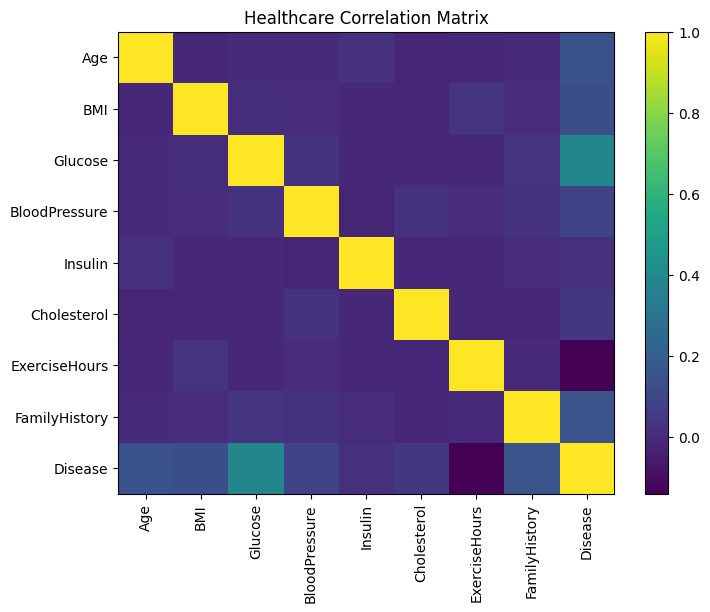


Pearson Correlation: Glucose vs BMI
Correlation: 0.008312184996257684
p-value: 0.6490407161747721

Spearman Correlation: Glucose vs BMI
Correlation: -0.001199004392566473
p-value: 0.9476605967432992


In [21]:
# Correlation analysis


corr_matrix = health_df[
    [
        "Age",
        "BMI",
        "Glucose",
        "BloodPressure",
        "Insulin",
        "Cholesterol",
        "ExerciseHours",
        "FamilyHistory",
        "Disease"
    ]
].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.colorbar()
plt.title("Healthcare Correlation Matrix")
plt.show()

pearson_corr, pearson_p = stats.pearsonr(health_df["Glucose"], health_df["BMI"])
spearman_corr, spearman_p = stats.spearmanr(health_df["Glucose"], health_df["BMI"])

print("\nPearson Correlation: Glucose vs BMI")
print("Correlation:", pearson_corr)
print("p-value:", pearson_p)

print("\nSpearman Correlation: Glucose vs BMI")
print("Correlation:", spearman_corr)
print("p-value:", spearman_p)



In [22]:
# Point-biserial correlation
pb_corr, pb_p = pointbiserialr(
    health_df["Disease"],
    health_df["Glucose"]
)

print("\nPoint-Biserial Correlation: Disease vs Glucose")
print("Correlation:", pb_corr)
print("p-value:", pb_p)



Point-Biserial Correlation: Disease vs Glucose
Correlation: 0.38111765323886415
p-value: 2.5579929995895582e-104


In [23]:
# Logistic regression model
# Predict disease


features = [
    "Age",
    "BMI",
    "Glucose",
    "BloodPressure",
    "Insulin",
    "Cholesterol",
    "ExerciseHours",
    "FamilyHistory"
]

X = health_df[features]
y = health_df["Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("\nLogistic Regression Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Logistic Regression Evaluation:
Accuracy: 0.7146666666666667
Precision: 0.6539923954372624
Recall: 0.5830508474576271
F1-score: 0.6164874551971327
ROC-AUC: 0.7789010989010989

Confusion Matrix:
[[364  91]
 [123 172]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       455
           1       0.65      0.58      0.62       295

    accuracy                           0.71       750
   macro avg       0.70      0.69      0.69       750
weighted avg       0.71      0.71      0.71       750



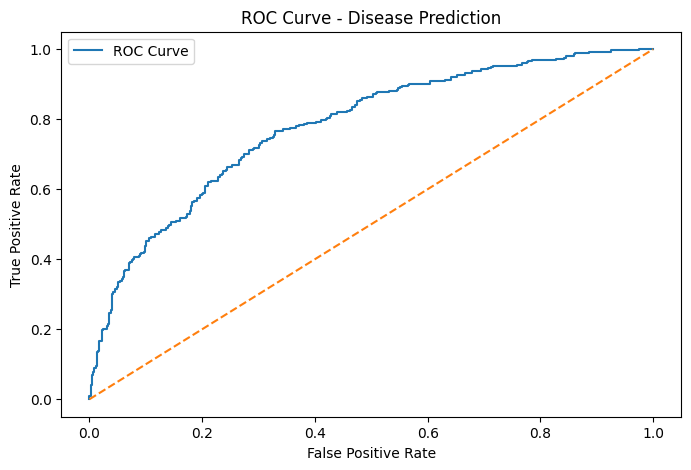

In [24]:
# ROC curve


fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Disease Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()



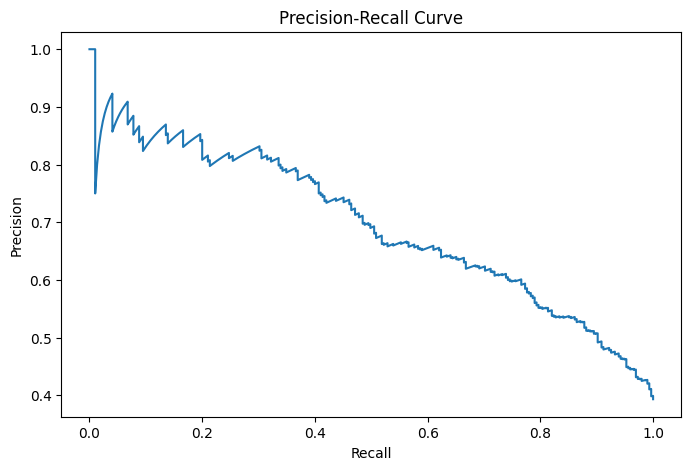

In [25]:
# Precision-recall curve


precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()



In [26]:
# Threshold tuning
# Healthcare-specific


thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

print("\nThreshold Tuning Results:")
print(threshold_df)

print("""
Healthcare Interpretation:
Lower threshold usually increases recall.
Higher recall means fewer high-risk patients are missed.
In healthcare screening, recall is often more important than precision.
""")




Threshold Tuning Results:
   Threshold  Accuracy  Precision    Recall        F1
0        0.3  0.665333   0.550459  0.813559  0.656635
1        0.4  0.710667   0.614035  0.711864  0.659341
2        0.5  0.714667   0.653992  0.583051  0.616487
3        0.6  0.720000   0.734807  0.450847  0.558824
4        0.7  0.694667   0.823529  0.284746  0.423174

Healthcare Interpretation:
Lower threshold usually increases recall.
Higher recall means fewer high-risk patients are missed.
In healthcare screening, recall is often more important than precision.



In [27]:
# Statsmodels logistic regression
# For p-values, coefficients, odds ratios

X_sm = sm.add_constant(X)

logit_model = sm.Logit(y, X_sm).fit()

print("\nStatsmodels Logistic Regression Summary:")
print(logit_model.summary())

odds_ratios = np.exp(logit_model.params)

conf = logit_model.conf_int()
conf["Odds Ratio Lower"] = np.exp(conf[0])
conf["Odds Ratio Upper"] = np.exp(conf[1])
conf["Odds Ratio"] = odds_ratios

print("\nOdds Ratios with Confidence Intervals:")
print(conf[["Odds Ratio", "Odds Ratio Lower", "Odds Ratio Upper"]])




Optimization terminated successfully.
         Current function value: 0.539392
         Iterations 6

Statsmodels Logistic Regression Summary:
                           Logit Regression Results                           
Dep. Variable:                Disease   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2991
Method:                           MLE   Df Model:                            8
Date:                Mon, 24 Aug 2026   Pseudo R-squ.:                  0.1955
Time:                        22:00:32   Log-Likelihood:                -1618.2
converged:                       True   LL-Null:                       -2011.5
Covariance Type:            nonrobust   LLR p-value:                1.535e-164
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -9.0400      0.530    -17.045      0.000   


Random Forest Feature Importance:
         Feature  Importance
2        Glucose    0.489581
1            BMI    0.113562
0            Age    0.092711
6  ExerciseHours    0.088087
3  BloodPressure    0.062561
7  FamilyHistory    0.059260
5    Cholesterol    0.056847
4        Insulin    0.037390


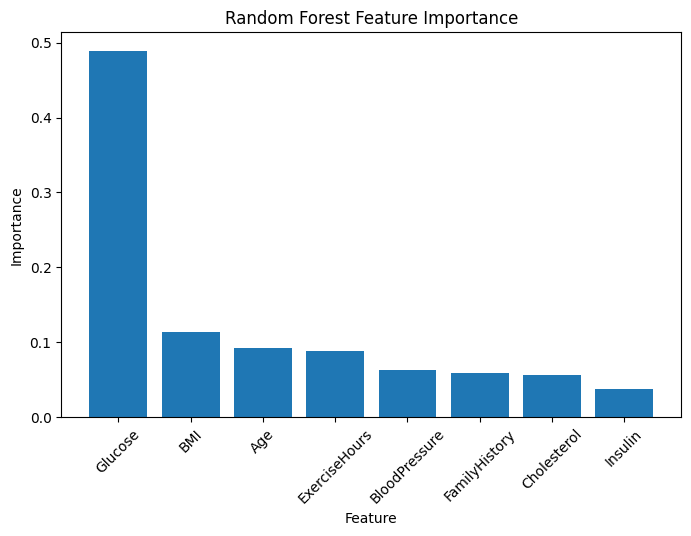

In [28]:
# Random forest feature importance


rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=5
)

rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nRandom Forest Feature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()


In [29]:
# Final interpretation


print("\nFinal Healthcare Statistical Interpretation:")
print("""
1. Disease probability increases with glucose, BMI, age, cholesterol, and family history.
2. Patients with high glucose have a higher conditional probability of disease.
3. Bayes theorem helps interpret the real probability of disease after a positive test.
4. T-tests and non-parametric tests validate whether health metrics differ significantly across disease groups.
5. Chi-square test checks whether categorical risk groups such as BMI category are associated with disease.
6. Logistic regression provides interpretable odds ratios.
7. ROC-AUC measures overall classification quality.
8. In healthcare, recall is very important because false negatives can be dangerous.
9. Random forest feature importance can be compared with logistic regression p-values.
10. Statistical significance and practical clinical importance should both be considered.
""")


Final Healthcare Statistical Interpretation:

1. Disease probability increases with glucose, BMI, age, cholesterol, and family history.
2. Patients with high glucose have a higher conditional probability of disease.
3. Bayes theorem helps interpret the real probability of disease after a positive test.
4. T-tests and non-parametric tests validate whether health metrics differ significantly across disease groups.
5. Chi-square test checks whether categorical risk groups such as BMI category are associated with disease.
6. Logistic regression provides interpretable odds ratios.
7. ROC-AUC measures overall classification quality.
8. In healthcare, recall is very important because false negatives can be dangerous.
9. Random forest feature importance can be compared with logistic regression p-values.
10. Statistical significance and practical clinical importance should both be considered.

